In [2]:
import torch
from PIL import Image as PILImage, ImageDraw
import requests
from io import BytesIO
import numpy as np
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry
import os

# Step 1: Load the SAM model (if not already loaded)
sam_checkpoint = "sam_vit_h_4b8939.pth"
if not os.path.exists(sam_checkpoint):
    print(f"Downloading {sam_checkpoint}...")
    url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
    response = requests.get(url)
    with open(sam_checkpoint, "wb") as f:
        f.write(response.content)
    print("Download completed.")

model_type = "vit_h"
device = "cuda" if torch.cuda.is_available() else "cpu"
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device)

def compute_iou(mask1, mask2):
    """Compute Intersection over Union (IoU) between two binary masks."""
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    iou = intersection / union if union > 0 else 0
    return iou

def group_masks_by_overlap(masks, iou_threshold=0.5):
    """Group masks into subsets based on overlap using IoU."""
    mask_subsets = []
    used_masks = set()
    
    for i, mask_data in enumerate(masks):
        if i in used_masks:
            continue
        
        main_mask = mask_data['segmentation']
        subset = [mask_data]
        used_masks.add(i)
        
        for j, other_mask_data in enumerate(masks):
            if i == j or j in used_masks:
                continue
            
            other_mask = other_mask_data['segmentation']
            iou = compute_iou(main_mask, other_mask)
            
            if iou > iou_threshold:
                subset.append(other_mask_data)
                used_masks.add(j)
        
        mask_subsets.append(subset)
    
    return mask_subsets

def visualize_main_objects(image_pil, mask_subsets):
    """Overlay original image with bounding boxes of the main object in each subset."""
    image_copy = image_pil.copy()
    draw = ImageDraw.Draw(image_copy)
    main_bboxes = []
    
    for subset in mask_subsets:
        if len(subset) > 1:
            main_mask_data = subset[0]  # Assume the first mask in the subset is the main object
            bbox = main_mask_data['bbox']
            main_bboxes.append(bbox)
            
            # Convert the bbox from XYWH to (x1, y1, x2, y2) format for drawing
            x1, y1, w, h = bbox
            x2 = x1 + w
            y2 = y1 + h
            
            # Draw the bounding box
            draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
    
    # Display the final image with all main object bounding boxes
    display(image_copy)
    
    return main_bboxes


import time

def detect_object_regions(image_url, iou_threshold=0.5):
    # Start timing the function
    start_time = time.time()
    
    # Load the image from the URL
    response_start = time.time()
    response = requests.get(image_url)
    image_pil = PILImage.open(BytesIO(response.content)).convert('RGB')
    image = np.array(image_pil)
    response_end = time.time()
    print(f"Image loading time: {response_end - response_start:.2f} seconds")
    
    # Step 4: Generate masks for the image
    mask_gen_start = time.time()
    mask_generator = SamAutomaticMaskGenerator(sam)

    mask_gen_start_2 = time.time()

    masks = mask_generator.generate(image)
    mask_gen_end = time.time()
    print(f"Mask generation time: {mask_gen_end - mask_gen_start:.2f} seconds")
    print(f"Mask generation time (just generation): {mask_gen_end - mask_gen_start_2:.2f} seconds")
    
    # Step 5: Group masks by overlap using IoU
    group_start = time.time()
    mask_subsets = group_masks_by_overlap(masks, iou_threshold)
    group_end = time.time()
    print(f"Grouping masks time: {group_end - group_start:.2f} seconds")
    
    # Step 6: Visualize the main objects and return the results
    visualize_start = time.time()
    main_bboxes = visualize_main_objects(image_pil, mask_subsets)
    visualize_end = time.time()
    print(f"Visualization time: {visualize_end - visualize_start:.2f} seconds")
    
    # End timing the function
    end_time = time.time()
    print(f"Total execution time: {end_time - start_time:.2f} seconds")
    
    return masks, mask_subsets, main_bboxes

Image loading time: 0.09 seconds
Mask generation time: 3.45 seconds
Mask generation time (just generation): 3.45 seconds
Grouping masks time: 0.33 seconds


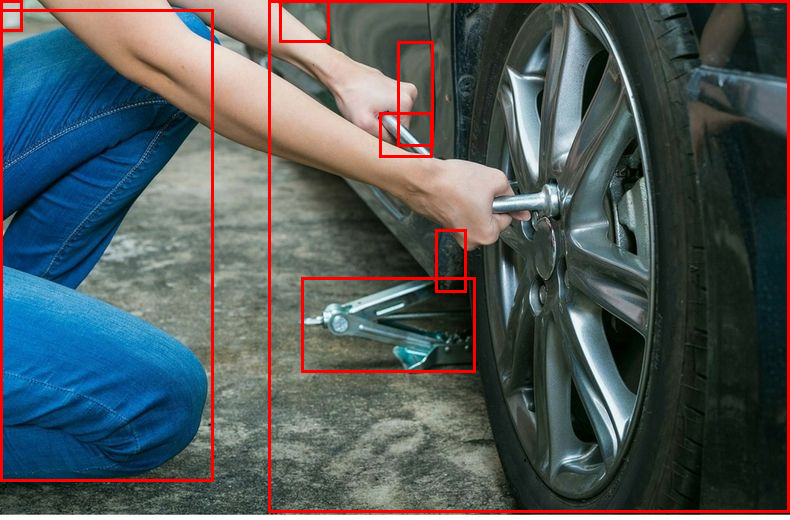

Visualization time: 0.08 seconds
Total execution time: 3.95 seconds


In [3]:
# Example usage
image_url = 'https://d1gymyavdvyjgt.cloudfront.net/drive/images/uploads/headers/ws_cropper/1_0x0_790x520_0x520_flattyre.jpg'
masks, mask_subsets, main_bboxes = detect_object_regions(image_url, iou_threshold=0.1)

In [4]:
urls = ['https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSXI1R0RQffwpBOzMOnvocu5WGgFcUNHsgzWg&s',
        'https://i.ytimg.com/vi/QauQpxsS-2U/hqdefault.jpg?sqp=-oaymwEmCOADEOgC8quKqQMa8AEB-AHOBYAClgOKAgwIABABGGUgUShCMA8=&rs=AOn4CLDE7DZDcQFnsjLsVWiqB8CsOH8T4w',
        'https://www.pennzoil.com/en_us/education/know-your-oil/changing-your-own-oil/_jcr_content/par/textimage_1798946642/image.img.480.jpeg/1458668286472/DIY%2520PZ%2520step12.jpeg?imformat=chrome&imwidth=480',
        'https://blog.esslinger.com/wp-content/uploads/2016/01/Replacing_A_Watch_Battery.jpg',
        'https://www.familyhandyman.com/wp-content/uploads/2022/06/Install-a-Window-Air-Conditioner-FH_WINDOW-AIR_06_29_012-JVedit.jpg?fit=640%2C640',
        'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQupWqZoyTUw8x6ZNAWUYrL2iuCp4YToDhaOA&s',
        'https://www.bhg.com/thmb/fr3wk2Dpp8FWlXZPBxiRbvZVvJU=/4000x0/filters:no_upscale():strip_icc()/BG_How-to_Clean_Dishwasher_3215-Step-02-52d83099c7024bfca9f83db67afcf432.jpg',
        'https://contentgrid.homedepot-static.com/hdus/en_US/DTCCOMNEW/Articles/how-to-install-a-kitchen-faucet-step-6.jpg',
        'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSEHIvMhNMskk42a6hTzaQ8TVuuN8PAjnyUkA&s',
        'https://i.ytimg.com/vi/4VIHTgUEhQc/sddefault.jpg']


In [1]:
for url in urls:
    try:
        masks, mask_subsets, main_bboxes = detect_object_regions(url, iou_threshold=0.25)
    except:
        continue

NameError: name 'urls' is not defined